In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
path = '/Users/qianj/Library/Mobile Documents/com~apple~CloudDocs/AA_2024-2026 job/Erdos_Project'

In [3]:
df_pushed_year = pd.read_csv(f'{path}/Modeling/common_NPI_pushed_year_df_with_pca_1_scaled_type_tot_risk_covid_3.csv').drop('Unnamed: 0',axis=1)
df_origin = pd.read_csv(f'{path}/Modeling/original_year_with_type_risk_tot_risk_pca_covid_3.csv').drop('Unnamed: 0', axis=1)

In [4]:
df_train = df_pushed_year[df_pushed_year['year']<=2021].copy()
df_val = df_origin[df_origin['year']==2021].copy() # use 2021 data predict for 2022, the df_origin dataset is in original year
df_val['year']=2022
df_val['Is_Covid']=0
actual_total_y = sum(df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt'])
actual_y = df_origin[df_origin['year']==2022]['Tot_Mdcr_Pymt_Amt']
actual_total_y

106979419226.792

In [5]:
df_2022 = df_origin[df_origin['year']==2022].copy()
df_2022['year'] = 2023
actual_total_2023 = sum(df_origin[df_origin['year']==2023]['Tot_Mdcr_Pymt_Amt'])

# Preprocessing Columns

In [6]:
label_cols = ['APP_Tot_Risk','PrimaryCare_Tot_Risk','MedicalSpecialtyOther_Tot_Risk','LabPathology_Tot_Risk','PharmacyNutrition_Tot_Risk']

def label_num_to_cat(df,cols):
    for c in cols:
        df[c] = df[c].astype(int).astype('object')
    return

In [7]:
label_num_to_cat(df_train,label_cols)
label_num_to_cat(df_val,label_cols)
label_num_to_cat(df_2022,label_cols)

In [8]:
from sklearn.preprocessing import OneHotEncoder

def enc_df(df):
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c not in ['Rndrng_NPI', 'Tot_HCPCS_Cds', 'Tot_Srvcs','Tot_Mdcr_Pymt_Amt','pca_1_scaled']]
    cat_cols = df.select_dtypes(exclude='number').columns.tolist()
    cat_cols = [c for c in cat_cols if c!='Rndrng_Prvdr_State_Abrvtn']

    cat_orders = []

    for c in cat_cols:
        cat_orders.append(df[c].unique().tolist())

    enc = OneHotEncoder(
        categories=cat_orders,
        handle_unknown='ignore',
        sparse_output=False,
        feature_name_combiner=lambda feature,category: f'{feature.split('_')[-1]}_{category}' if 'Rndrng' in feature else f'{feature}_{category}'
    )

    X_cat = enc.fit_transform(df[cat_cols])

    dummy_names = enc.get_feature_names_out(cat_cols)

    X_cat_df = pd.DataFrame(X_cat,columns=dummy_names,index=df.index)
    X_train = pd.concat([df[num_cols+['Tot_Mdcr_Pymt_Amt']],X_cat_df],axis=1)
    return X_train


In [9]:
X_train = enc_df(df_train)
X_val = enc_df(df_val)

In [24]:
X_train['Tot_Mdcr_Pymt_Amt'] = X_train['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)
X_val['Tot_Mdcr_Pymt_Amt'] = X_val['Tot_Mdcr_Pymt_Amt'].apply(lambda x:x if x!=0 else 1)
X_train['Tot_Benes'] = X_train['Tot_Benes'].apply(lambda x:x if x!=0 else 1)
X_val['Tot_Benes'] = X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)

In [25]:
X_train['Log_Amt']  = np.log(X_train['Tot_Mdcr_Pymt_Amt'])
X_val['Log_Amt']  = np.log(X_val['Tot_Mdcr_Pymt_Amt'])

In [12]:
df_2022 = enc_df(df_2022)

In [68]:
RESULT_DF = pd.DataFrame(columns=['formula','val_percentage','train_percentage','val_measure','train_measure','abs_val_percentage'])
RESULT_DF

,formula,val_percentage,train_percentage,val_measure,train_measure,abs_val_percentage


In [29]:
X_train.columns

Index(['Tot_Benes', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'Tot_Risk', 'year',
       'Is_Covid', 'Tot_Mdcr_Pymt_Amt', 'Cd_I', 'Cd_O', 'Type_PrimaryCare',
       'Type_LabPathology', 'Type_Anesthesia', 'Type_OBGYN',
       'Type_SurgeryOther', 'Type_CardioVascularSurgery', 'Type_APP',
       'Type_Cardiology', 'Type_MedicalSpecialtyOther', 'Type_RehabTherapy',
       'Type_FacilitySupplierProgram', 'Type_OncologyHeme',
       'Type_RadiologyImaging', 'Type_AcuteCare', 'Type_BehavioralHealth',
       'Type_VisionHearing', 'Type_PharmacyNutrition', 'Type_UnknownOther',
       'Ind_Y', 'Ind_N', 'APP_Tot_Risk_2', 'APP_Tot_Risk_1', 'APP_Tot_Risk_0',
       'PrimaryCare_Tot_Risk_0', 'PrimaryCare_Tot_Risk_2',
       'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_2',
       'MedicalSpecialtyOther_Tot_Risk_0', 'MedicalSpecialtyOther_Tot_Risk_1',
       'LabPathology_Tot_Risk_3', 'LabPathology_Tot_Risk_2',
       'LabPathology_Tot_Risk_0', 'LabPathology_Tot_Risk_1',
       'PharmacyNut

In [14]:
feature_cols = [c for c in X_train.columns.tolist() if c not in ['Tot_Benes','Tot_Risk','Tot_Mdcr_Pymt_Amt']]

In [69]:
RESULT_DF.to_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv')

In [ ]:
RESULT_DF = pd.read_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv').drop('Unnamed: 0',axis=1)
print(len("".join(RESULT_DF.sort_values('val_measure').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))

KeyError: 'val_deviance'

# Auto selection

In [30]:
def next_best_formula(result_df,col):
    if result_df.shape[0]==0:
        return 'Log_Amt~'
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    formula = 'Log_Amt~'
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

def feature_selection(result_df,col,feature_cols):
    FORMULA = next_best_formula(result_df,col)
    for c in feature_cols:
        if c not in FORMULA:
            if c=='year':
                formula = FORMULA + '+cr(year,df=3)'
            else:
                formula = FORMULA + f'+{c}'
            MODEL = smf.glm(
                formula = formula,
                data = X_train,
                family=sm.families.Gaussian(),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

            sigma2 = MODEL.scale

            pred_log = MODEL.predict(X_val,offset=np.log(X_val['Tot_Benes']))

            train_log = MODEL.predict(X_train,offset=np.log(X_train['Tot_Benes']))

            y_pred = np.exp(pred_log+0.5*sigma2)

            val_p = sum(y_pred)/actual_total_y

            train_p = sum(np.exp(train_log+0.5*sigma2))/sum(X_train['Tot_Mdcr_Pymt_Amt'])

            val_m = np.sum((pred_log-X_val['Log_Amt'])**2)

            train_m = np.sum((train_log-X_train['Log_Amt'])**2)

            temp = pd.DataFrame({
                'formula': [formula.replace('\n','').replace(' ','')[8:].split('+')],
                'val_percentage': [val_p],
                'train_percentage': [train_p],
                'val_measure':[val_m],
                'train_measure':[train_m],
                'abs_val_percentage':[abs(val_p-1)]
            })
            result_df = pd.concat([result_df,temp],axis=0)
    
    return result_df

In [170]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv').drop('Unnamed: 0',axis=1)
RESULT_DF.sort_values('abs_val_percentage')

,formula,val_percentage,train_percentage,val_measure,train_measure,abs_val_percentage
236,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",1.001032,1.043700,7.540875e+05,7.003870e+06,0.001032
280,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.998906,1.041736,7.282499e+05,6.805585e+06,0.001094
221,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.996621,0.999817,8.005739e+05,7.261596e+06,0.003379
197,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.996621,0.999817,8.005739e+05,7.261596e+06,0.003379
457,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.996145,1.036214,6.222666e+05,6.230451e+06,0.003855
...,...,...,...,...,...,...
49,"['APP_Tot_Risk_1', 'Bene_Avg_Age']",1.277296,1.293599,9.380317e+05,8.033437e+06,0.277296
57,"['APP_Tot_Risk_1', 'Type_Anesthesia']",1.280066,1.302192,9.197973e+05,7.933263e+06,0.280066
99,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'cr(ye...",1.306622,1.203841,8.854183e+05,7.781834e+06,0.306622
2,cr(yeardf=3),1.312670,1.230639,1.025484e+06,8.496525e+06,0.312670


In [141]:
def best_formula(result_df,col):
    features = "".join(result_df.sort_values(col).iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")
    print(result_df.sort_values(col).reset_index(drop=True).loc[0,:])
    print(features)
    print(len(features))
    formula = 'Log_Amt ~ '
    for x in features:
        formula+=f'{x}+'
    return formula[:-1]

In [171]:
best_formula(RESULT_DF,'abs_val_percentage')

formula               ['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...
val_percentage                                                 1.001032
train_percentage                                                 1.0437
val_measure                                                754087.45913
train_measure                                            7003870.102711
abs_val_percentage                                             0.001032
Name: 0, dtype: object
['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Bene_Avg_Risk_Scre']
6


'Log_Amt ~ APP_Tot_Risk_1+Type_RehabTherapy+Type_RadiologyImaging+Type_BehavioralHealth+Type_SurgeryOther+Bene_Avg_Risk_Scre'

In [172]:
best_formula(RESULT_DF,'val_measure')

formula               ['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...
val_percentage                                                 1.011822
train_percentage                                                1.05335
val_measure                                               607439.647643
train_measure                                            6215647.341023
abs_val_percentage                                             0.011822
Name: 0, dtype: object
['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Type_OncologyHeme', 'MedicalSpecialtyOther_Tot_Risk_0', 'PrimaryCare_Tot_Risk_1', 'Bene_Avg_Risk_Scre', 'Type_APP', 'Bene_Avg_Age']
11


'Log_Amt ~ APP_Tot_Risk_1+Type_RehabTherapy+Type_RadiologyImaging+Type_BehavioralHealth+Type_SurgeryOther+Type_OncologyHeme+MedicalSpecialtyOther_Tot_Risk_0+PrimaryCare_Tot_Risk_1+Bene_Avg_Risk_Scre+Type_APP+Bene_Avg_Age'

In [169]:
#print(best_formula(RESULT_DF,'val_measure'))
df = feature_selection(RESULT_DF,'val_measure',feature_cols)
df.to_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv')
df.sort_values('val_measure')

,formula,val_percentage,train_percentage,val_measure,train_measure,abs_val_percentage
0,"[APP_Tot_Risk_1, Type_RehabTherapy, Type_Radio...",1.011822,1.053350,6.074396e+05,6.215647e+06,0.011822
0,"[APP_Tot_Risk_1, Type_RehabTherapy, Type_Radio...",0.985468,1.038308,6.086866e+05,6.194050e+06,0.014532
0,"[APP_Tot_Risk_1, Type_RehabTherapy, Type_Radio...",0.980518,1.030400,6.132152e+05,6.218452e+06,0.019482
0,"[APP_Tot_Risk_1, Type_RehabTherapy, Type_Radio...",0.990698,1.041968,6.145706e+05,6.242566e+06,0.009302
0,"[APP_Tot_Risk_1, Type_RehabTherapy, Type_Radio...",0.990698,1.041968,6.145706e+05,6.242566e+06,0.009302
...,...,...,...,...,...,...
25,Ind_N,1.223791,1.231595,1.024591e+06,8.500758e+06,0.223791
48,state_Unknown,1.223823,1.231625,1.024592e+06,8.500759e+06,0.223823
46,state_Territory,1.224093,1.231937,1.024604e+06,8.500546e+06,0.224093
34,MedicalSpecialtyOther_Tot_Risk_1,1.223519,1.231736,1.024697e+06,8.500440e+06,0.223519


In [ ]:
# df['formula']=df['formula'].apply(lambda x:"".join(x).replace(' ','').replace(',',''))
# df['formula']

0                        Bene_Avg_Age
0                  Bene_Avg_Risk_Scre
0                        cr(yeardf=3)
0                            Is_Covid
0                                Cd_I
0                                Cd_O
0                    Type_PrimaryCare
0                   Type_LabPathology
0                     Type_Anesthesia
0                          Type_OBGYN
0                   Type_SurgeryOther
0          Type_CardioVascularSurgery
0                            Type_APP
0                     Type_Cardiology
0          Type_MedicalSpecialtyOther
0                   Type_RehabTherapy
0        Type_FacilitySupplierProgram
0                   Type_OncologyHeme
0               Type_RadiologyImaging
0                      Type_AcuteCare
0               Type_BehavioralHealth
0                  Type_VisionHearing
0              Type_PharmacyNutrition
0                   Type_UnknownOther
0                               Ind_Y
0                               Ind_N
0           

In [81]:
df.to_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv')


In [ ]:
RESULT_DF=pd.read_csv(f'{path}/Modeling/LOGNORMAL_RESULTS_7.csv').drop('Unnamed: 0',axis=1)
print(len("".join(RESULT_DF.sort_values('val_deviance').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))
RESULT_DF.sort_values('val_deviance').iat[0,0]

14


"['Type_OncologyHeme', 'Type_RehabTherapy', 'Type_BehavioralHealth', 'PrimaryCare_Tot_Risk_1', 'MedicalSpecialtyOther_Tot_Risk_0', 'Type_SurgeryOther', 'APP_Tot_Risk_0', 'Type_CardioVascularSurgery', 'Type_VisionHearing', 'Type_Cardiology', 'MedicalSpecialtyOther_Tot_Risk_2', 'Is_Covid', 'Type_UnknownOther', 'Ind_N']"

## Model_1 val_measure

formula               ['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...
val_percentage                                                 1.011822
train_percentage                                                1.05335
val_measure                                               607439.647643
train_measure                                            6215647.341023
abs_val_percentage                                             0.011822
Name: 0, dtype: object
['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Type_OncologyHeme', 'MedicalSpecialtyOther_Tot_Risk_0', 'PrimaryCare_Tot_Risk_1', 'Bene_Avg_Risk_Scre', 'Type_APP', 'Bene_Avg_Age']
11
1.0118221996029229


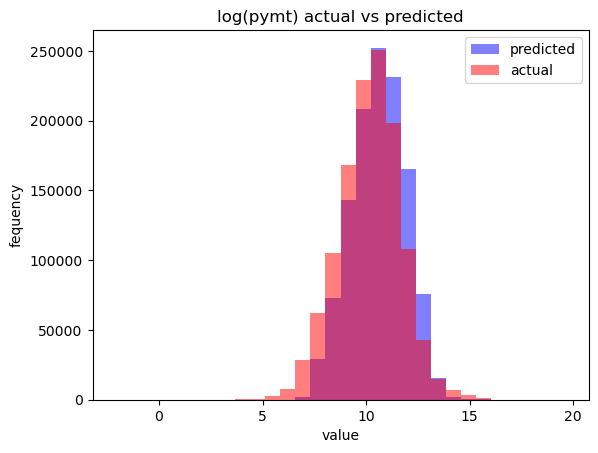

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Log_Amt   No. Observations:              7956527
Model:                            GLM   Df Residuals:                  7956515
Model Family:                Gaussian   Df Model:                           11
Link Function:               Identity   Scale:                         0.78120
Method:                          IRLS   Log-Likelihood:            -1.0307e+07
Date:                Tue, 10 Mar 2026   Deviance:                   6.2156e+06
Time:                        18:52:59   Pearson chi2:                 6.22e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.3076
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [173]:
formula = best_formula(RESULT_DF,'val_measure')

MODEL_1 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gaussian(),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

log_pred = MODEL_1.predict(X_val,offset=np.log(X_val['Tot_Benes']))

sigma2 = MODEL_1.scale

y_pred = np.exp(log_pred+0.5*sigma2)

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_1.summary())

In [174]:
summary_df = pd.DataFrame({
    "coef": MODEL_1.params,
    "p_value": MODEL_1.pvalues,
    # "std_err": MODEL_1.bse,
    # "z": MODEL_1.tvalues   # for GLM this is usually z-stat
})

summary_df = summary_df.sort_values("p_value")

print(summary_df)

                                      coef  p_value
Intercept                         3.643273      0.0
APP_Tot_Risk_1                   -1.860664      0.0
Type_RehabTherapy                 1.029135      0.0
Type_RadiologyImaging            -0.878331      0.0
Type_BehavioralHealth             1.122841      0.0
Type_SurgeryOther                 0.757512      0.0
Type_OncologyHeme                 1.350784      0.0
MedicalSpecialtyOther_Tot_Risk_0  0.977112      0.0
PrimaryCare_Tot_Risk_1            0.715393      0.0
Bene_Avg_Risk_Scre                0.219221      0.0
Type_APP                          1.574565      0.0
Bene_Avg_Age                      0.013939      0.0


In [175]:
print('2023 ratio = ',sum(np.exp(0.5*MODEL_1.scale+MODEL_1.predict(df_2022,offset=np.log(df_2022['Tot_Benes']))))/actual_total_2023)

2023 ratio =  0.911673216377187


## Model_2 abs_val_percentage

formula               ['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...
val_percentage                                                 1.001032
train_percentage                                                 1.0437
val_measure                                                754087.45913
train_measure                                            7003870.102711
abs_val_percentage                                             0.001032
Name: 0, dtype: object
['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Bene_Avg_Risk_Scre']
6
1.0010324828364412


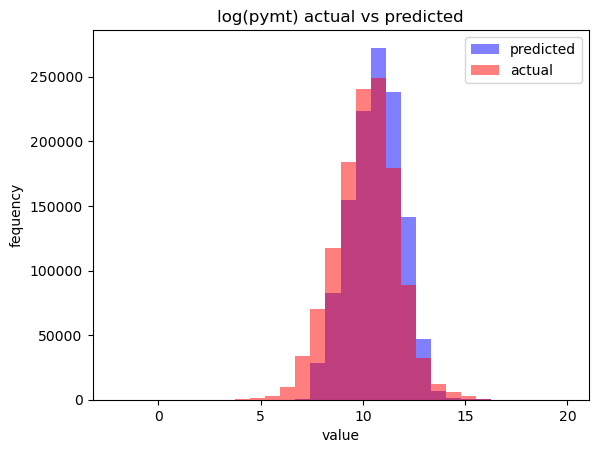

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Log_Amt   No. Observations:              7956527
Model:                            GLM   Df Residuals:                  7956520
Model Family:                Gaussian   Df Model:                            6
Link Function:               Identity   Scale:                         0.88027
Method:                          IRLS   Log-Likelihood:            -1.0782e+07
Date:                Tue, 10 Mar 2026   Deviance:                   7.0039e+06
Time:                        18:28:54   Pearson chi2:                 7.00e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1924
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.93

In [148]:
formula = best_formula(RESULT_DF,'abs_val_percentage')

MODEL_2 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gaussian(),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

log_pred = MODEL_2.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

y_pred = np.exp(log_pred+0.5*MODEL_2.scale)

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_2.summary())

In [149]:
summary_df = pd.DataFrame({
    "coef": MODEL_2.params,
    "p_value": MODEL_2.pvalues,
    # "std_err": MODEL_1.bse,
    # "z": MODEL_1.tvalues   # for GLM this is usually z-stat
})

summary_df = summary_df.sort_values("p_value")

print(summary_df)

                           coef  p_value
Intercept              4.930021      0.0
APP_Tot_Risk_1        -0.525681      0.0
Type_RehabTherapy      0.793844      0.0
Type_RadiologyImaging -1.086118      0.0
Type_BehavioralHealth  0.757942      0.0
Type_SurgeryOther      0.546580      0.0
Bene_Avg_Risk_Scre     0.175914      0.0


In [150]:
print('2023 ratio = ',sum(np.exp(0.5*MODEL_2.scale+MODEL_2.predict(df_2022,offset=np.log(df_2022['Tot_Benes']))))/actual_total_2023)

2023 ratio =  0.8885714557718349


## Model 3

In [152]:
def top_x_perc_mask(df,col,x):
    cutoff = df[col].quantile(x)
    return df[col]<=cutoff

In [158]:
x = 0.05
mask_dev = top_x_perc_mask(RESULT_DF,'val_measure',x)
mask_per = top_x_perc_mask(RESULT_DF,'abs_val_percentage',x)

print("".join(RESULT_DF[mask_dev&mask_per].sort_values('val_measure').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(","))
print(len("".join(RESULT_DF[mask_dev&mask_per].sort_values('val_measure').iat[0,0]).strip("[ ]'").replace("'",'').replace(" ",'').split(",")))
RESULT_DF[mask_dev&mask_per]

['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Type_OncologyHeme', 'MedicalSpecialtyOther_Tot_Risk_0', 'PrimaryCare_Tot_Risk_1', 'LabPathology_Tot_Risk_3']
9


,formula,val_percentage,train_percentage,val_measure,train_measure,abs_val_percentage
371,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.993402,1.017777,679429.423377,6.501779e+06,0.006598
391,"['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...",0.993402,1.017777,679429.423376,6.501779e+06,0.006598


formula               ['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_...
val_percentage                                                 0.993402
train_percentage                                               1.017777
val_measure                                               679429.423376
train_measure                                            6501779.479845
abs_val_percentage                                             0.006598
Name: 0, dtype: object
['APP_Tot_Risk_1', 'Type_RehabTherapy', 'Type_RadiologyImaging', 'Type_BehavioralHealth', 'Type_SurgeryOther', 'Type_OncologyHeme', 'MedicalSpecialtyOther_Tot_Risk_0', 'PrimaryCare_Tot_Risk_1', 'LabPathology_Tot_Risk_3']
9
0.9934019572165117


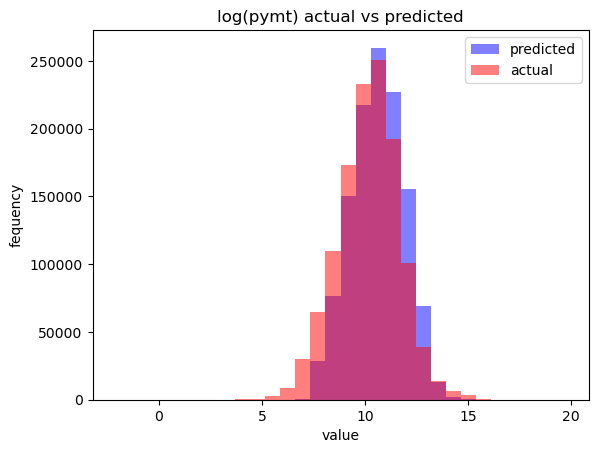

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Log_Amt   No. Observations:              7956527
Model:                            GLM   Df Residuals:                  7956517
Model Family:                Gaussian   Df Model:                            9
Link Function:               Identity   Scale:                         0.81716
Method:                          IRLS   Log-Likelihood:            -1.0487e+07
Date:                Tue, 10 Mar 2026   Deviance:                   6.5018e+06
Time:                        18:31:41   Pearson chi2:                 6.50e+06
No. Iterations:                     3   Pseudo R-squ. (CS):             0.2647
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [159]:
formula = best_formula(RESULT_DF[mask_dev&mask_per],'abs_val_percentage')

MODEL_3 = smf.glm(
                formula = formula,
                data = X_train,
                family = sm.families.Gaussian(),
                offset = np.log(X_train['Tot_Benes'])
            ).fit()

log_pred = MODEL_3.predict(X_val,offset=np.log(X_val['Tot_Benes'].apply(lambda x:x if x!=0 else 1)))

y_pred = np.exp(log_pred+0.5*MODEL_3.scale)

print(sum(y_pred)/actual_total_y)

log_y_pred = np.log(y_pred.apply(lambda x:x if x!=0 else 1))
log_actual_y = np.log(actual_y.apply(lambda x:x if x!=0 else 1))

bins = np.histogram_bin_edges(np.concatenate([log_y_pred, log_actual_y]), bins=30)

plt.hist(log_y_pred, bins=bins, alpha=0.5, color="blue", label="predicted")
plt.hist(log_actual_y, bins=bins, alpha=0.5, color='red',label='actual')

plt.legend()
plt.xlabel('value')
plt.ylabel('fequency')
plt.title('log(pymt) actual vs predicted')
plt.show()

print(MODEL_3.summary())

In [160]:
print('2023 ratio = ',sum(np.exp(0.5*MODEL_3.scale+MODEL_3.predict(df_2022,offset=np.log(df_2022['Tot_Benes']))))/actual_total_2023)

2023 ratio =  0.8865702501435571


## It looks like Model_2 wins in terms of predicting the total pymt